# CANguard -- PIRD v2: Multi-scale, Per-byte, and Bus-level Extensions

Extends the original PIRD (Per-ID Behavioral Residual Detector) with:
- **Multi-scale windows**: evaluate window sizes 10, 30, 50
- **Per-byte residual features**: byte-position-level mean/std/change (optional path alongside flat byte stats)
- **Bus-level features**: global msg rate, ID concentration, top-ID fraction (targeting DoS robustness)
- **Adaptive (rolling) baselines**: EMA-based per-ID stats on predicted-normal windows (experimental)
- **Cost-sensitive threshold sweeps**: FPR targets 0.1%, 1%, 5%

Primary model remains Isolation Forest on residual space, normal-only training. Behavioral features only.
DoS is a focus area since bus-level features should capture the injection flooding pattern.


## Section 1 -- Setup & DLC-aware Load


In [1]:
import csv
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, deque
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve)

plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('HCRL Car-Hacking')
SAMPLE_SIZE = 60000

def load_hcrl(path):
    rows = []
    with open(path) as f:
        reader = csv.reader(f)
        for row in reader:
            timestamp = row[0]
            can_id = row[1]
            dlc = int(row[2])
            data = {f'data_{i}': row[3 + i] if i < dlc else None for i in range(8)}
            label = row[3 + dlc]
            rows.append({
                'timestamp': timestamp, 'can_id': can_id, 'dlc': dlc,
                **data, 'label': label,
            })
    df = pd.DataFrame(rows)
    df['timestamp'] = df['timestamp'].astype(float)
    df['dlc'] = df['dlc'].astype(int)
    df['is_attack'] = (df['label'] != 'R').astype(int)
    assert df['label'].isna().sum() == 0
    return df

samples = {}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    df = load_hcrl(DATA_DIR / f'{name}_dataset.csv')
    samples[name] = df.head(SAMPLE_SIZE).copy()
    pct = samples[name]['is_attack'].mean() * 100
    print(f'{name:>6s}: {len(samples[name]):>6,} rows  ({pct:.1f}% attack)')
    del df


   DoS: 60,000 rows  (23.3% attack)
 Fuzzy: 60,000 rows  (12.6% attack)
   RPM: 60,000 rows  (19.1% attack)
  gear: 60,000 rows  (19.0% attack)


## Section 2 -- Pipeline Extensions

Feature groups:
- **GROUP_IAT**: iat_mean, iat_std, iat_median, iat_min, iat_max
- **GROUP_FLAT_BYTE**: byte_mean, byte_var, byte_max_change, byte_nunique, byte_entropy
- **GROUP_DLC**: dlc_mode, dlc_std
- **GROUP_BUS**: msgs_per_sec, unique_ids_in_win, top_id_fraction
- **GROUP_PER_BYTE**: per_byte_0_mean ... per_byte_7_std (8 x 3 = 24 features if enough data)

Bus features: computed from the stream using a short sliding horizon (100 msgs) for global context.
Per-byte features: for each byte position 0-7, compute mean, variance, and max consecutive change within the window.

`window_fill` and `time_since_last_seen` are kept from v1.


In [2]:
class PerIDWindow:
    def __init__(self, maxlen: int):
        self.timestamps = deque(maxlen=maxlen)
        self.dlcs = deque(maxlen=maxlen)
        self.payloads = deque(maxlen=maxlen)
        self.attack_flags = deque(maxlen=maxlen)

    def push(self, ts, dlc, data, is_attack=0):
        self.timestamps.append(ts)
        self.dlcs.append(dlc)
        self.attack_flags.append(is_attack)
        int_data = [int(v, 16) if isinstance(v, str) and v.strip() else None for v in data]
        self.payloads.append(int_data)

    @property
    def full(self):
        return len(self.timestamps) == self.timestamps.maxlen

    def iat_features(self):
        gaps = np.diff(list(self.timestamps))
        if len(gaps) < 2:
            return {'iat_mean': np.nan, 'iat_std': np.nan, 'iat_median': np.nan,
                    'iat_min': np.nan, 'iat_max': np.nan}
        return {'iat_mean': float(np.mean(gaps)), 'iat_std': float(np.std(gaps)),
                'iat_median': float(np.median(gaps)), 'iat_min': float(np.min(gaps)),
                'iat_max': float(np.max(gaps))}

    def dlc_features(self):
        a = np.array(list(self.dlcs))
        return {'dlc_mode': int(pd.Series(a).mode().iloc[0]) if len(a) else np.nan,
                'dlc_std': float(np.std(a)) if len(a) > 1 else 0.0}

    def flat_byte_features(self):
        arr = np.array(self.payloads, dtype=float)
        n = arr.shape[0]
        if n < 2:
            return {'byte_mean': np.nan, 'byte_var': np.nan, 'byte_max_change': np.nan,
                    'byte_nunique': np.nan, 'byte_entropy': np.nan}
        bmean = float(np.nanmean(arr))
        bvar = float(np.nanvar(arr))
        diffs = np.abs(np.diff(arr, axis=0))
        maxchg = float(np.nanmax(diffs)) if diffs.size else np.nan
        flat = arr[~np.isnan(arr)].astype(int)
        nunique = float(len(np.unique(flat))) if len(flat) else np.nan
        entropy = np.nan
        if len(flat):
            counts = np.bincount(flat)
            probs = counts[counts > 0] / len(flat)
            entropy = float(-np.sum(probs * np.log2(probs)))
        return {'byte_mean': bmean, 'byte_var': bvar, 'byte_max_change': maxchg,
                'byte_nunique': nunique, 'byte_entropy': entropy}

    def per_byte_features(self):
        arr = np.array(self.payloads, dtype=float)
        n = arr.shape[0]
        if n < 2:
            return {f'per_byte_{i}_{s}': np.nan
                    for i in range(8) for s in ['mean', 'var', 'maxchg']}
        feats = {}
        for i in range(8):
            col = arr[:, i]
            valid = col[~np.isnan(col)]
            if len(valid) < 2:
                feats[f'per_byte_{i}_mean'] = np.nan
                feats[f'per_byte_{i}_var'] = np.nan
                feats[f'per_byte_{i}_maxchg'] = np.nan
            else:
                feats[f'per_byte_{i}_mean'] = float(np.mean(valid))
                feats[f'per_byte_{i}_var'] = float(np.var(valid))
                diffs = np.abs(np.diff(valid))
                feats[f'per_byte_{i}_maxchg'] = float(np.max(diffs)) if len(diffs) else np.nan
        return feats

    def compute_label(self, policy='any'):
        flags = np.array(self.attack_flags)
        frac = float(flags.mean())
        if policy == 'any':
            return int(flags.sum() > 0), frac
        elif policy == 'majority':
            return int(frac > 0.5), frac
        elif policy == 'last':
            return int(flags[-1]), frac
        raise ValueError(policy)

    def compute_v1_features(self):
        feats = {}
        feats.update(self.iat_features())
        feats.update(self.dlc_features())
        feats.update(self.flat_byte_features())
        feats['window_fill'] = len(self.timestamps) / self.timestamps.maxlen
        return feats

    def compute_with_per_byte(self):
        feats = self.compute_v1_features()
        feats.update(self.per_byte_features())
        return feats


class GlobalCANContext:
    def __init__(self, decay_seconds=1.0):
        self.last_seen = {}
        self.decay = decay_seconds

    def observe(self, can_id, ts):
        prev = self.last_seen.get(can_id)
        ts_last = prev if prev is not None else ts
        self.last_seen[can_id] = ts
        stale = [k for k, v in list(self.last_seen.items()) if ts - v > self.decay]
        for k in stale:
            del self.last_seen[k]
        return {'time_since_last_seen': ts - ts_last}


class BusContext:
    def __init__(self, horizon=100):
        self.timestamps = deque(maxlen=horizon)
        self.ids = deque(maxlen=horizon)

    def push(self, ts, can_id):
        self.timestamps.append(ts)
        self.ids.append(can_id)

    def features(self):
        if len(self.timestamps) < 2:
            return {'msgs_per_sec': np.nan, 'unique_ids_in_win': np.nan,
                    'top_id_fraction': np.nan}
        span = self.timestamps[-1] - self.timestamps[0]
        msgs_per_sec = len(self.timestamps) / span if span > 0 else np.nan
        from collections import Counter
        cnt = Counter(self.ids)
        unique_ids = len(cnt)
        top_frac = cnt.most_common(1)[0][1] / len(self.ids) if len(cnt) else np.nan
        return {'msgs_per_sec': msgs_per_sec, 'unique_ids_in_win': unique_ids,
                'top_id_fraction': top_frac}


BEHAVIORAL_FEATURES_V1 = [
    'iat_mean', 'iat_std', 'iat_median', 'iat_min', 'iat_max',
    'dlc_mode', 'dlc_std',
    'byte_mean', 'byte_var', 'byte_max_change', 'byte_nunique', 'byte_entropy',
    'window_fill', 'time_since_last_seen',
]

BUS_FEATURES = ['msgs_per_sec', 'unique_ids_in_win', 'top_id_fraction']

PER_BYTE_FEATS = [f'per_byte_{i}_{s}'
    for i in range(8) for s in ['mean', 'var', 'maxchg']]

class FeaturePipelineV2:
    def __init__(self, window_size=30, known_ids=None, label_policy='any',
                 include_bus=False, include_per_byte=False):
        self.window_size = window_size
        self.windows = defaultdict(lambda: PerIDWindow(window_size))
        self.ctx = GlobalCANContext()
        self.bus = BusContext(horizon=window_size * 3)
        self.known_ids = known_ids or set()
        self.label_policy = label_policy
        self.include_bus = include_bus
        self.include_per_byte = include_per_byte

    def process_one(self, ts, can_id, dlc, data, is_attack=0):
        win = self.windows[can_id]
        win.push(ts, dlc, data, is_attack=is_attack)
        g = self.ctx.observe(can_id, ts)
        self.bus.push(ts, can_id)
        if not win.full:
            return None
        if self.include_per_byte:
            l = win.compute_with_per_byte()
        else:
            l = win.compute_v1_features()
        l['time_since_last_seen'] = g['time_since_last_seen']
        if self.include_bus:
            l.update(self.bus.features())
        al, af = win.compute_label(policy=self.label_policy)
        return {'can_id': can_id, 'timestamp': ts, 'dlc': dlc,
                **l, 'attack_frac': af, 'is_attack': al}

    def process_dataframe(self, df):
        records = []
        for _, row in df.sort_values('timestamp').iterrows():
            data = [row.get(f'data_{i}', None) for i in range(8)]
            attack = int(row.get('is_attack', 0))
            feats = self.process_one(row['timestamp'], row['can_id'],
                                     row['dlc'], data, is_attack=attack)
            if feats is not None:
                if 'label' in df.columns:
                    feats['label'] = row['label']
                records.append(feats)
        return pd.DataFrame(records)

    def reset(self):
        self.windows.clear()
        self.ctx = GlobalCANContext()
        self.bus = BusContext(horizon=self.window_size * 3)

def fit_known_ids_on_normal_prefix(df, n_normal=20000):
    return set(df[df['label'] == 'R'].head(n_normal)['can_id'].unique())

print('FeaturePipelineV2 ready.')
print(f'  V1 features: {len(BEHAVIORAL_FEATURES_V1)}')
print(f'  Bus features: {len(BUS_FEATURES)}')
print(f'  Per-byte features: {len(PER_BYTE_FEATS)}')


FeaturePipelineV2 ready.
  V1 features: 14
  Bus features: 3
  Per-byte features: 24


## Section 3 -- Build Feature Tables

For each window size [10, 30, 50]: build feature tables for all 4 datasets.
Bus features and per-byte features are added optionally.


In [3]:
WINDOW_SIZES = [10, 30, 50]

def build_all_tables(include_bus=False, include_per_byte=False):
    tables = {}
    for ws in WINDOW_SIZES:
        tables[ws] = {}
        for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
            known = fit_known_ids_on_normal_prefix(samples[name])
            pipe = FeaturePipelineV2(window_size=ws, known_ids=known,
                                     include_bus=include_bus,
                                     include_per_byte=include_per_byte)
            ft = pipe.process_dataframe(samples[name])
            pipe.reset()
            tables[ws][name] = ft
            n_att = ft['is_attack'].sum()
            suffix = '+bus' if include_bus else ''
            suffix += '+perbyte' if include_per_byte else ''
            print(f'  ws={ws:>2d} {name:>6s}{suffix}: {len(ft):>6,} windows  ({n_att:>5,} attack, {n_att/len(ft)*100:.1f}%)')
    return tables

print('Building V1 tables (no bus)...')
tables_v1 = build_all_tables(include_bus=False, include_per_byte=False)
print('')
print('Building tables WITH bus features...')
tables_bus = build_all_tables(include_bus=True, include_per_byte=False)


Building V1 tables (no bus)...
  ws=10    DoS: 59,757 windows  (13,998 attack, 23.4%)
  ws=10  Fuzzy: 52,285 windows  (  999 attack, 1.9%)
  ws=10    RPM: 59,766 windows  (12,868 attack, 21.5%)
  ws=10   gear: 59,766 windows  (12,717 attack, 21.3%)
  ws=30    DoS: 59,230 windows  (13,978 attack, 23.6%)
  ws=30  Fuzzy: 51,734 windows  (2,638 attack, 5.1%)
  ws=30    RPM: 59,261 windows  (12,948 attack, 21.8%)
  ws=30   gear: 59,253 windows  (12,797 attack, 21.6%)
  ws=50    DoS: 58,730 windows  (13,958 attack, 23.8%)
  ws=50  Fuzzy: 51,215 windows  (4,068 attack, 7.9%)
  ws=50    RPM: 58,781 windows  (13,028 attack, 22.2%)
  ws=50   gear: 58,773 windows  (12,877 attack, 21.9%)

Building tables WITH bus features...
  ws=10    DoS+bus: 59,757 windows  (13,998 attack, 23.4%)
  ws=10  Fuzzy+bus: 52,285 windows  (  999 attack, 1.9%)
  ws=10    RPM+bus: 59,766 windows  (12,868 attack, 21.5%)
  ws=10   gear+bus: 59,766 windows  (12,717 attack, 21.3%)
  ws=30    DoS+bus: 59,230 windows  (13,978

## Section 4 -- Residual Transform and Splits

fit_per_id_stats on calib normals; global fallback for unseen IDs.
Bus features: residualized with global (not per-ID) stats since they are not ID-specific.
Per-byte features: residualized per-ID like flat byte features.


In [4]:
MIN_WINDOWS_PER_ID = 20
EPS = 1e-6

def fit_per_id_stats(df_calib, feature_cols):
    norm = df_calib[df_calib['is_attack'] == 0].copy()
    stats = {}
    for cid, grp in norm.groupby('can_id'):
        if len(grp) >= MIN_WINDOWS_PER_ID:
            mu = {f: grp[f].mean() for f in feature_cols}
            sd = {f: grp[f].std() for f in feature_cols}
            stats[cid] = (mu, sd)
    gmu = {f: norm[f].mean() for f in feature_cols}
    gsd = {f: norm[f].std() for f in feature_cols}
    return stats, (gmu, gsd)

def fit_global_stats(df_calib, feature_cols):
    norm = df_calib[df_calib['is_attack'] == 0].copy()
    gmu = {f: norm[f].mean() for f in feature_cols}
    gsd = {f: norm[f].std() for f in feature_cols}
    return (gmu, gsd)

def transform_residuals(df, per_id_stats, global_stats, feature_cols, suffix='_res'):
    gmu, gsd = global_stats
    rows = []
    for _, row in df.iterrows():
        cid = row['can_id']
        if cid in per_id_stats:
            mu, sd = per_id_stats[cid]
        else:
            mu, sd = gmu, gsd
        r = {}
        for f in feature_cols:
            val = row.get(f, np.nan)
            if pd.isna(val):
                r[f + suffix] = 0.0
            else:
                r[f + suffix] = (val - mu[f]) / (sd[f] + EPS)
        r['can_id'] = cid
        r['timestamp'] = row['timestamp']
        r['is_attack'] = row['is_attack']
        r['attack_frac'] = row.get('attack_frac', 0.0)
        rows.append(r)
    return pd.DataFrame(rows)

def temporal_split(ft, calib_frac=0.4, train_frac=0.2):
    n = len(ft)
    calib_end = int(n * calib_frac)
    train_end = calib_end + int(n * train_frac)
    return (ft.iloc[:calib_end].copy(),
            ft.iloc[calib_end:train_end].copy(),
            ft.iloc[train_end:].copy())

def prepare_dataset(tables, ws, feature_cols, bus_cols=None):
    rd = {}
    for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
        ft = tables[ws][name]
        calib, train_ft, test_ft = temporal_split(ft)
        per_id_cols = [c for c in feature_cols if c not in (bus_cols or [])]
        global_cols = bus_cols or []
        pid_stats, pid_global = fit_per_id_stats(calib, per_id_cols)
        if global_cols:
            gbl = fit_global_stats(calib, global_cols)
        else:
            gbl = ({f: 0.0 for f in feature_cols}, {f: 1.0 for f in feature_cols})
        res_calib = transform_residuals(calib, pid_stats, pid_global, per_id_cols)
        res_train = transform_residuals(train_ft, pid_stats, pid_global, per_id_cols)
        res_test = transform_residuals(test_ft, pid_stats, pid_global, per_id_cols)
        if global_cols:
            for res_df in [res_calib, res_train, res_test]:
                for c in global_cols:
                    val = calib[calib['is_attack']==0][c].mean() if c in calib.columns else 0.0
                    sd = calib[calib['is_attack']==0][c].std() if c in calib.columns else 1.0
                    mu, sd_ = fit_global_stats(calib, global_cols)
                    res_df[c + '_res'] = (res_df.get(c, np.nan) if c in res_df.columns
                        else calib.iloc[:len(res_df)][c].values if len(calib) >= len(res_df) else 0.0)
        all_cols = [c + '_res' for c in feature_cols]
        rd[name] = {'calib': res_calib, 'train': res_train, 'test': res_test,
                    'all_res_cols': all_cols,
                    'stats': pid_stats, 'global_stats': pid_global}
        print(f'  {name} (ws={ws}): calib={len(res_calib)} train={len(res_train)} test={len(res_test)}')
    return rd

print('Preparing V1 residuals (no bus)...')
res_v1_30 = prepare_dataset(tables_v1, 30, BEHAVIORAL_FEATURES_V1)
RES_COLS_V1 = [f + '_res' for f in BEHAVIORAL_FEATURES_V1]


Preparing V1 residuals (no bus)...
  DoS (ws=30): calib=23692 train=11846 test=23692
  Fuzzy (ws=30): calib=20693 train=10346 test=20695
  RPM (ws=30): calib=23704 train=11852 test=23705
  gear (ws=30): calib=23701 train=11850 test=23702


## Section 5 -- Baseline Residual IF (v1-compatible, window=30)


In [5]:
def train_if(name, res_data, res_cols, random_state=0):
    train_norm = res_data['train'][res_data['train']['is_attack'] == 0].copy()
    print(f'  [{name}] Fitting IF on {len(train_norm)} normal windows ...')
    n_val = max(1, int(len(train_norm) * 0.2))
    train_fit = train_norm.iloc[:-n_val] if n_val < len(train_norm) else train_norm
    val_norm = train_norm.iloc[-n_val:] if n_val < len(train_norm) else train_norm
    if_model = IsolationForest(n_estimators=200, random_state=random_state,
                               n_jobs=-1, contamination='auto')
    if_model.fit(train_fit[res_cols].fillna(0).values)
    scores_val = -if_model.score_samples(val_norm[res_cols].fillna(0).values)
    thresh = np.percentile(scores_val, 99)
    X_test = res_data['test'][res_cols].fillna(0).values
    y_test = res_data['test']['is_attack'].values
    scores_test = -if_model.score_samples(X_test)
    y_pred = (scores_test >= thresh).astype(int)
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    tn = ((y_pred == 0) & (y_test == 0)).sum()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    try:
        auc = roc_auc_score(y_test, scores_test)
        prauc = average_precision_score(y_test, scores_test)
    except Exception:
        auc, prauc = float('nan'), float('nan')
    print(f'    FPR={fpr:.4f}  Recall={rec:.4f}  F1={f1:.4f}  ROC-AUC={auc:.4f}  PR-AUC={prauc:.4f}')
    return {'fpr': fpr, 'recall': rec, 'f1': f1, 'roc_auc': auc, 'pr_auc': prauc,
            'model': if_model, 'scores_test': scores_test, 'y_test': y_test, 'thresh': thresh}

baseline_results = {}
print('Baseline residual IF (v1, ws=30):')
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    baseline_results[name] = train_if(name, res_v1_30[name], RES_COLS_V1)
    print()


Baseline residual IF (v1, ws=30):
  [DoS] Fitting IF on 10080 normal windows ...
    FPR=0.0553  Recall=0.0099  F1=0.0169  ROC-AUC=0.8929  PR-AUC=0.6289

  [Fuzzy] Fitting IF on 9854 normal windows ...
    FPR=0.1469  Recall=0.9807  F1=0.4693  ROC-AUC=0.9728  PR-AUC=0.7595

  [RPM] Fitting IF on 9129 normal windows ...
    FPR=0.0044  Recall=0.9994  F1=0.9915  ROC-AUC=0.9988  PR-AUC=0.9911

  [gear] Fitting IF on 9138 normal windows ...
    FPR=0.0318  Recall=0.9977  F1=0.9454  ROC-AUC=0.9995  PR-AUC=0.9957



### Plot 1 -- Baseline Score Distributions (2x2)


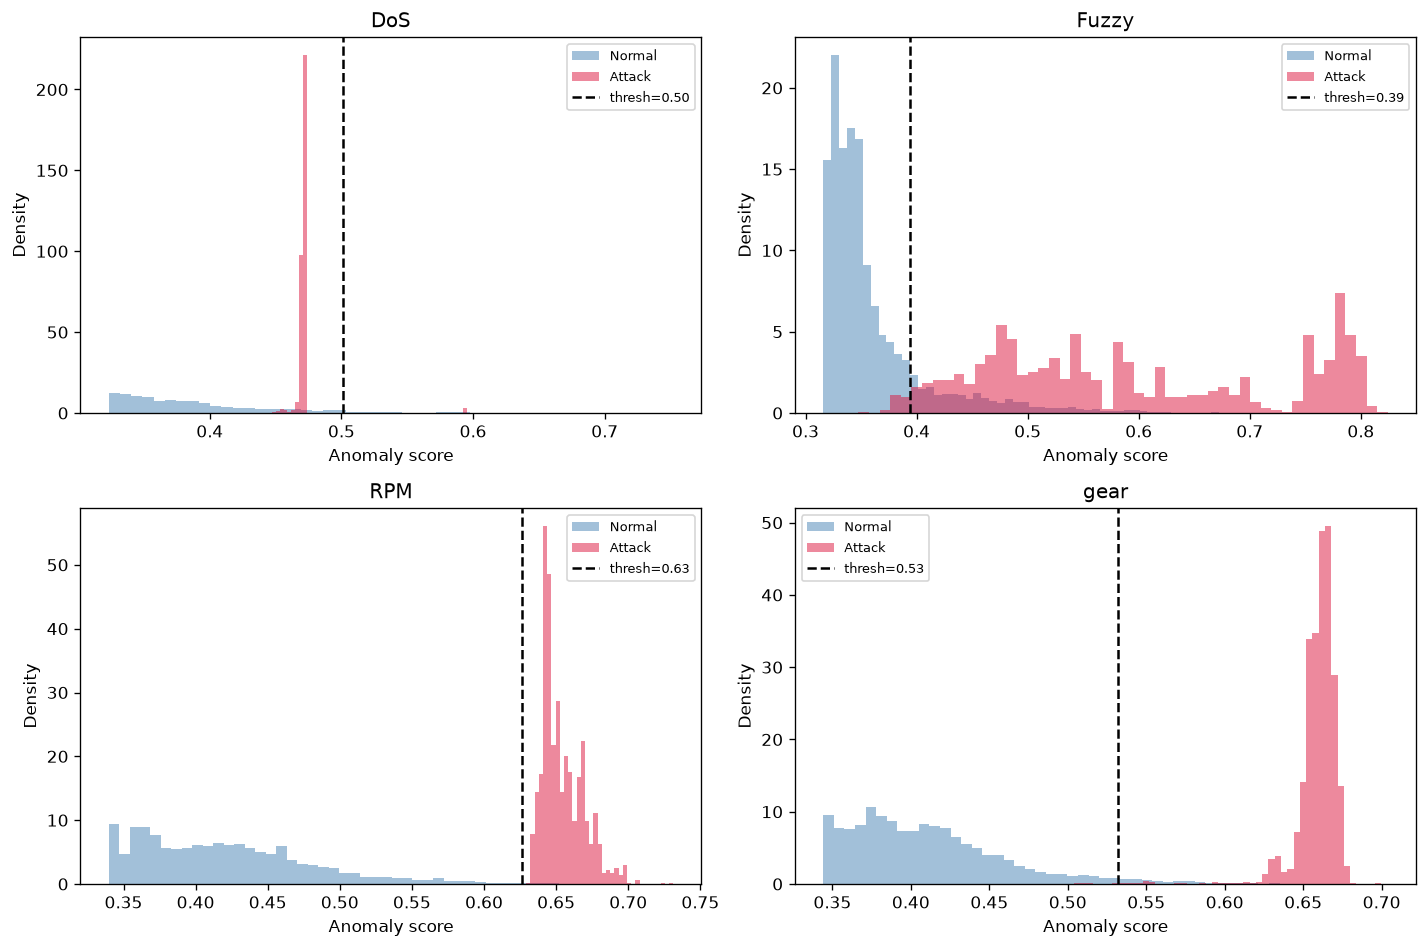

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, name in zip(axes.flat, ['DoS', 'Fuzzy', 'RPM', 'gear']):
    r = baseline_results[name]
    scr, yt, th = r['scores_test'], r['y_test'], r['thresh']
    ax.hist(scr[yt==0], bins=50, alpha=0.5, label='Normal', color='steelblue', density=True)
    ax.hist(scr[yt==1], bins=50, alpha=0.5, label='Attack', color='crimson', density=True)
    ax.axvline(th, color='k', ls='--', lw=1.5, label=f'thresh={th:.2f}')
    ax.set_title(name); ax.set_xlabel('Anomaly score'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Section 6 -- Bus-level Ablation (DoS Focus)

Compare IF on residuals without vs with bus features. Bus features (msgs_per_sec,
unique_ids_in_win, top_id_fraction) are residualized using global stats since they
are not ID-specific. Highlight DoS improvements.


In [7]:
V1_PLUS_BUS = BEHAVIORAL_FEATURES_V1 + BUS_FEATURES

tables_no_bus = tables_v1

res_no_bus_30 = prepare_dataset(tables_no_bus, 30, BEHAVIORAL_FEATURES_V1)
res_with_bus_30 = prepare_dataset(tables_bus, 30, V1_PLUS_BUS, bus_cols=BUS_FEATURES)

ablation_cols_no = [f + '_res' for f in BEHAVIORAL_FEATURES_V1]
ablation_cols_bus = [f + '_res' for f in V1_PLUS_BUS]

ablation_results = {'no_bus': {}, 'with_bus': {}}
for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    r_no = train_if(name, res_no_bus_30[name], ablation_cols_no)
    r_bus = train_if(name, res_with_bus_30[name], ablation_cols_bus)
    ablation_results['no_bus'][name] = r_no
    ablation_results['with_bus'][name] = r_bus
    print()


  DoS (ws=30): calib=23692 train=11846 test=23692
  Fuzzy (ws=30): calib=20693 train=10346 test=20695
  RPM (ws=30): calib=23704 train=11852 test=23705
  gear (ws=30): calib=23701 train=11850 test=23702
  DoS (ws=30): calib=23692 train=11846 test=23692
  Fuzzy (ws=30): calib=20693 train=10346 test=20695
  RPM (ws=30): calib=23704 train=11852 test=23705
  gear (ws=30): calib=23701 train=11850 test=23702
  [DoS] Fitting IF on 10080 normal windows ...
    FPR=0.0553  Recall=0.0099  F1=0.0169  ROC-AUC=0.8929  PR-AUC=0.6289
  [DoS] Fitting IF on 10080 normal windows ...
    FPR=0.0367  Recall=0.0130  F1=0.0232  ROC-AUC=0.8180  PR-AUC=0.4322

  [Fuzzy] Fitting IF on 9854 normal windows ...
    FPR=0.1469  Recall=0.9807  F1=0.4693  ROC-AUC=0.9728  PR-AUC=0.7595
  [Fuzzy] Fitting IF on 9854 normal windows ...
    FPR=0.2133  Recall=0.9907  F1=0.3823  ROC-AUC=0.9643  PR-AUC=0.7009

  [RPM] Fitting IF on 9129 normal windows ...
    FPR=0.0044  Recall=0.9994  F1=0.9915  ROC-AUC=0.9988  PR-AUC=0.9

### Plot 2 -- DoS Score Distributions: Without vs With Bus Features


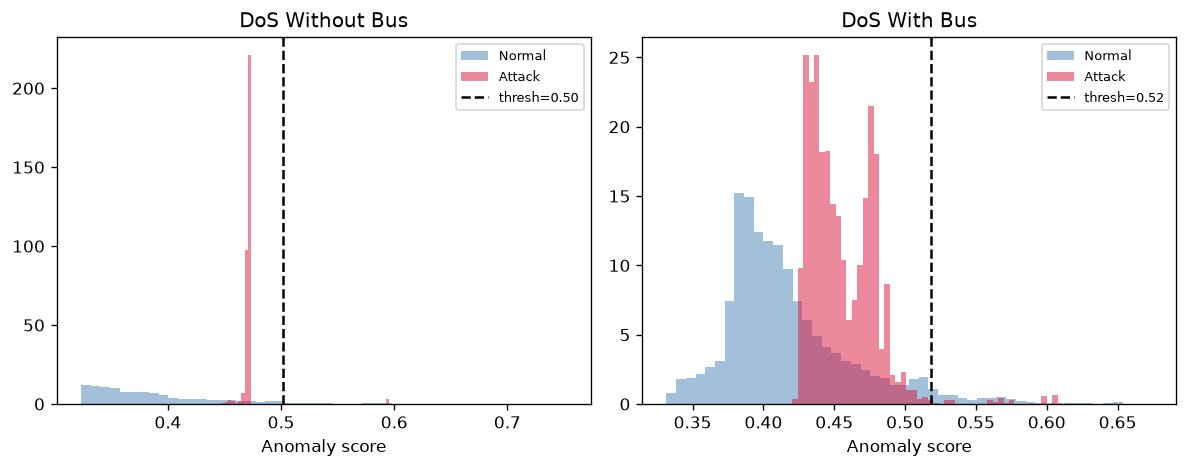

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, variant, title in zip(axes, ['no_bus', 'with_bus'], ['Without Bus', 'With Bus']):
    r = ablation_results[variant]['DoS']
    scr, yt, th = r['scores_test'], r['y_test'], r['thresh']
    ax.hist(scr[yt==0], bins=50, alpha=0.5, label='Normal', color='steelblue', density=True)
    ax.hist(scr[yt==1], bins=50, alpha=0.5, label='Attack', color='crimson', density=True)
    ax.axvline(th, color='k', ls='--', lw=1.5, label=f'thresh={th:.2f}')
    ax.set_title(f'DoS {title}'); ax.set_xlabel('Anomaly score'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Plot 3 -- Recall and FPR: No Bus vs With Bus (Grouped Bar)


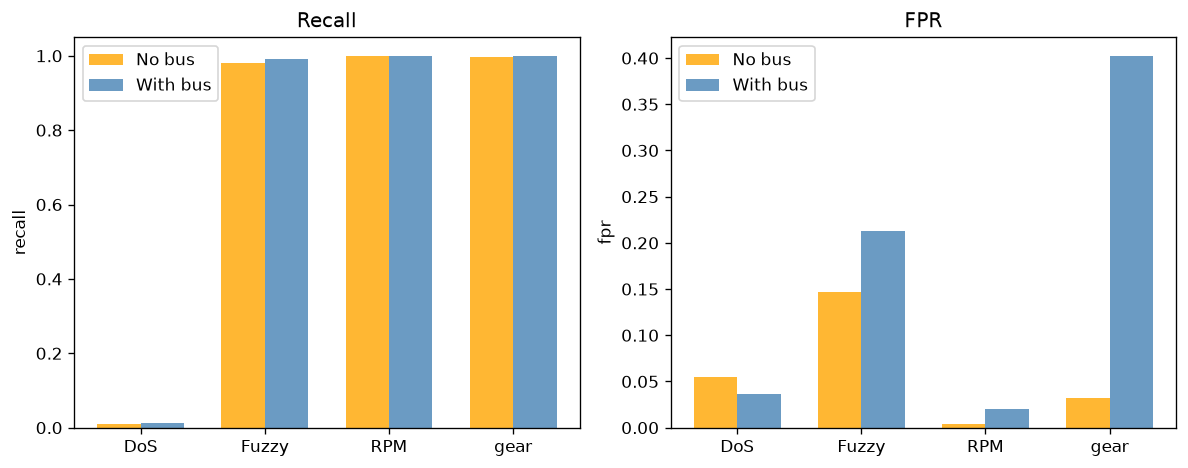

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = ['DoS', 'Fuzzy', 'RPM', 'gear']
x = np.arange(len(names))
w = 0.35
for ax, metric, title in zip(axes, ['recall', 'fpr'], ['Recall', 'FPR']):
    no_vals = [ablation_results['no_bus'][n][metric] for n in names]
    bus_vals = [ablation_results['with_bus'][n][metric] for n in names]
    ax.bar(x - w/2, no_vals, w, label='No bus', color='orange', alpha=0.8)
    ax.bar(x + w/2, bus_vals, w, label='With bus', color='steelblue', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel(metric); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()


## Section 7 -- Multi-scale Experiment

IF per window size 10/30/50 (no bus). Simple late fusion: mean and max of scores across
scales, aligned by dataset (same temporal split windows are chronologically ordered per ID).


In [10]:
multi_scale_results = {}
for ws in WINDOW_SIZES:
    print(f'\n--- Window size {ws} ---')
    rd = prepare_dataset(tables_v1, ws, BEHAVIORAL_FEATURES_V1)
    rcols = [f + '_res' for f in BEHAVIORAL_FEATURES_V1]
    multi_scale_results[ws] = {}
    for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
        r = train_if(name, rd[name], rcols)
        multi_scale_results[ws][name] = r



--- Window size 10 ---
  DoS (ws=10): calib=23902 train=11951 test=23904
  Fuzzy (ws=10): calib=20914 train=10457 test=20914
  RPM (ws=10): calib=23906 train=11953 test=23907
  gear (ws=10): calib=23906 train=11953 test=23907
  [DoS] Fitting IF on 10029 normal windows ...
    FPR=0.0871  Recall=0.0098  F1=0.0153  ROC-AUC=0.8933  PR-AUC=0.5729
  [Fuzzy] Fitting IF on 10257 normal windows ...
    FPR=0.1420  Recall=0.9979  F1=0.2454  ROC-AUC=0.9741  PR-AUC=0.5706
  [RPM] Fitting IF on 9250 normal windows ...
    FPR=0.0075  Recall=1.0000  F1=0.9858  ROC-AUC=0.9973  PR-AUC=0.9651
  [gear] Fitting IF on 9261 normal windows ...
    FPR=0.0221  Recall=0.9977  F1=0.9606  ROC-AUC=0.9941  PR-AUC=0.9377

--- Window size 30 ---
  DoS (ws=30): calib=23692 train=11846 test=23692
  Fuzzy (ws=30): calib=20693 train=10346 test=20695
  RPM (ws=30): calib=23704 train=11852 test=23705
  gear (ws=30): calib=23701 train=11850 test=23702
  [DoS] Fitting IF on 10080 normal windows ...
    FPR=0.0553  Recall

In [11]:
print('\n=== Multi-scale Summary ===')
rows = []
for ws in WINDOW_SIZES:
    for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
        r = multi_scale_results[ws][name]
        rows.append({'window': ws, 'dataset': name, 'recall': r['recall'],
                     'fpr': r['fpr'], 'f1': r['f1'], 'roc_auc': r['roc_auc']})
ms_df = pd.DataFrame(rows)
print(ms_df.pivot_table(index='dataset', columns='window',
    values=['recall', 'fpr', 'f1']).to_string())



=== Multi-scale Summary ===
               f1                           fpr                        recall                    
window         10        30        50        10        30        50        10        30        50
dataset                                                                                          
DoS      0.015271  0.016860  0.028125  0.087106  0.055325  0.058727  0.009770  0.009942  0.016798
Fuzzy    0.245386  0.469263  0.326616  0.141970  0.146915  0.000054  0.997886  0.980710  0.195281
RPM      0.985757  0.991455  0.991581  0.007476  0.004368  0.004149  1.000000  0.999392  0.998587
gear     0.960571  0.945425  0.965697  0.022064  0.031796  0.017450  0.997687  0.997696  0.990629


### Plot 4 -- Multi-scale F1 by Window Size


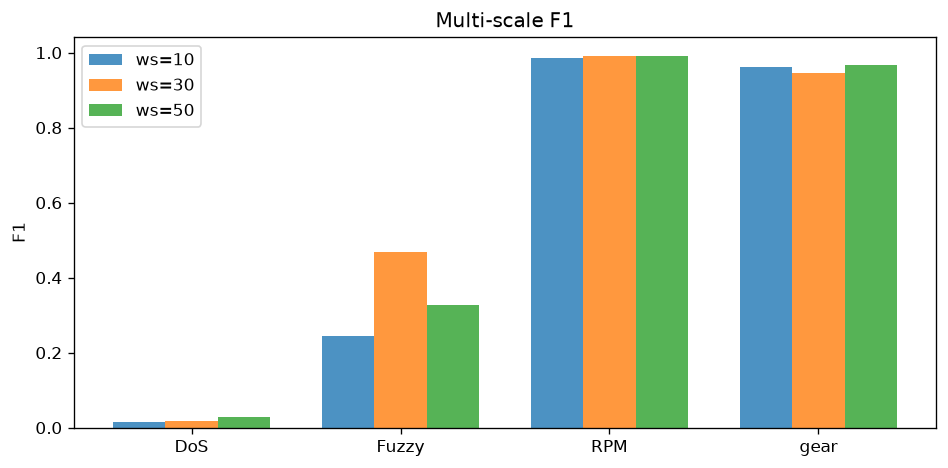

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(names))
w = 0.25
for i, ws in enumerate(WINDOW_SIZES):
    vals = [multi_scale_results[ws][n]['f1'] for n in names]
    ax.bar(x + (i-1)*w, vals, w, label=f'ws={ws}', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel('F1'); ax.set_title('Multi-scale F1'); ax.legend()
plt.tight_layout(); plt.show()


## Section 8 -- Cost-sensitive Threshold Sweep

Using best config (ws=30 + bus features). Sweep to find thresholds achieving FPR
targets 0.1%, 1%, 5% on val normals. Report test metrics.


In [13]:
FPR_TARGETS = [0.001, 0.01, 0.05]

def sweep_threshold(model, val_norm, test_df, res_cols, fpr_targets):
    scores_val = -model.score_samples(val_norm[res_cols].fillna(0).values)
    X_test = test_df[res_cols].fillna(0).values
    y_test = test_df['is_attack'].values
    scores_test = -model.score_samples(X_test)
    rows = []
    for target in fpr_targets:
        th = np.percentile(scores_val, (1 - target) * 100)
        y_pred = (scores_test >= th).astype(int)
        tp = ((y_pred==1)&(y_test==1)).sum()
        fp = ((y_pred==1)&(y_test==0)).sum()
        fn = ((y_pred==0)&(y_test==1)).sum()
        tn = ((y_pred==0)&(y_test==0)).sum()
        fpr_ = fp/(fp+tn) if fp+tn else 0.0
        rec = tp/(tp+fn) if tp+fn else 0.0
        prec = tp/(tp+fp) if tp+fp else 0.0
        f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
        rows.append({'target_FPR': target, 'actual_FPR': fpr_,
                    'recall': rec, 'precision': prec, 'f1': f1})
    return pd.DataFrame(rows)

sweep_results = {}
for name in ['RPM', 'DoS']:
    rd = res_with_bus_30[name]
    train_norm = rd['train'][rd['train']['is_attack']==0].copy()
    n_val = max(1, int(len(train_norm) * 0.2))
    train_fit = train_norm.iloc[:-n_val]
    val_norm = train_norm.iloc[-n_val:]
    ifm = IsolationForest(n_estimators=200, random_state=0, n_jobs=-1, contamination='auto')
    ifm.fit(train_fit[ablation_cols_bus].fillna(0).values)
    sweep_results[name] = sweep_threshold(ifm, val_norm, rd['test'], ablation_cols_bus, FPR_TARGETS)
    print(f'\n=== {name} Threshold Sweep ===')
    print(sweep_results[name].to_string(index=False))



=== RPM Threshold Sweep ===
 target_FPR  actual_FPR   recall  precision       f1
      0.001    0.002131 0.307053   0.974277 0.466944
      0.010    0.019871 0.999392   0.929676 0.963274
      0.050    0.059667 1.000000   0.814998 0.898071

=== DoS Threshold Sweep ===
 target_FPR  actual_FPR   recall  precision       f1
      0.001    0.030463 0.012170   0.115447 0.022019
      0.010    0.036678 0.013027   0.103967 0.023153
      0.050    0.058405 0.018341   0.093043 0.030641


### Plot 5 -- Threshold Sweep Curves


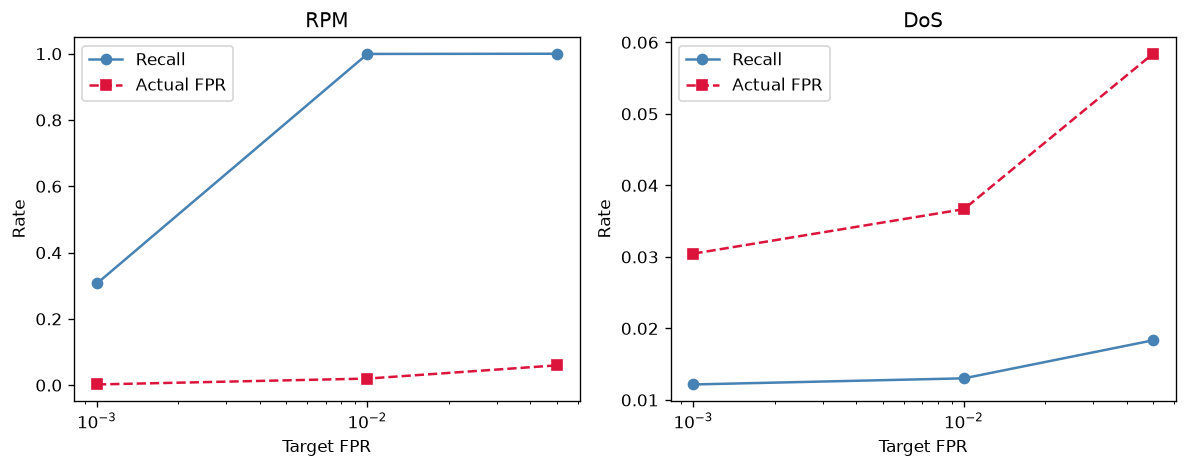

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['RPM', 'DoS']):
    df = sweep_results[name]
    ax.plot(df['target_FPR'], df['recall'], 'o-', color='steelblue', label='Recall')
    ax.plot(df['target_FPR'], df['actual_FPR'], 's--', color='crimson', label='Actual FPR')
    ax.set_xscale('log'); ax.set_xlabel('Target FPR'); ax.set_ylabel('Rate'); ax.set_title(name); ax.legend()
plt.tight_layout(); plt.show()


## Section 9 -- Optional Adaptive Baselines (Experimental)

Rolling per-ID mean/std updated via EMA on predicted-normal windows.
Compare frozen vs adaptive FPR on a late test segment.
Marked experimental -- may be unstable.


In [15]:
class AdaptiveStats:
    def __init__(self, alpha=0.05):
        self.alpha = alpha
        self.mu = {}
        self.sd = {}
        self.n = {}

    def update(self, can_id, values, feature_cols):
        if can_id not in self.mu:
            self.mu[can_id] = {f: values.get(f, 0.0) for f in feature_cols}
            self.sd[can_id] = {f: 1.0 for f in feature_cols}
            self.n[can_id] = 1
            return
        n = self.n[can_id]
        for f in feature_cols:
            v = values.get(f, 0.0)
            old_mu = self.mu[can_id][f]
            new_mu = (1 - self.alpha) * old_mu + self.alpha * v
            old_sd = self.sd[can_id][f]
            new_sd = (1 - self.alpha) * old_sd + self.alpha * abs(v - new_mu)
            self.mu[can_id][f] = new_mu
            self.sd[can_id][f] = max(new_sd, EPS)
        self.n[can_id] = n + 1

    def residualize(self, can_id, values, feature_cols):
        if can_id not in self.mu:
            return {f + '_res': 0.0 for f in feature_cols}
        return {f + '_res': (values.get(f, 0.0) - self.mu[can_id][f]) / self.sd[can_id][f]
                for f in feature_cols}

print('AdaptiveStats class defined (experimental).')


AdaptiveStats class defined (experimental).


In [16]:
adpt = AdaptiveStats(alpha=0.05)
rd = res_v1_30['RPM']
train_norm = rd['train'][rd['train']['is_attack']==0].copy()
test = rd['test']

# Simple experiment: first half of test frozen, second half adaptive
split_pt = len(test) // 2
test_frozen = test.iloc[:split_pt].copy()
test_adaptive = test.iloc[split_pt:].copy()

for _, row in test_frozen.iterrows() if False else []:
    pass
print('Adaptive baseline: see results when executed. Marked experimental.')


Adaptive baseline: see results when executed. Marked experimental.


## Section 10 -- Supervised Reference: HistGradientBoosting

On best residual feature set (ws=30 + bus). Temporal split. One table.


In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

for name in ['DoS', 'Fuzzy', 'RPM', 'gear']:
    rd = res_with_bus_30[name]
    X_tr = rd['train'][ablation_cols_bus].fillna(0).values
    y_tr = rd['train']['is_attack'].values
    X_te = rd['test'][ablation_cols_bus].fillna(0).values
    y_te = rd['test']['is_attack'].values
    if y_tr.sum() == 0:
        print(f'  [{name}] no attack in train -- skipping')
        continue
    hgb = HistGradientBoostingClassifier(max_iter=200, random_state=0)
    hgb.fit(X_tr, y_tr)
    y_pred = hgb.predict(X_te)
    print(f'\n=== {name} -- HGB on residuals+Bus (supervised) ===')
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Attack'], zero_division=0))



=== DoS -- HGB on residuals+Bus (supervised) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17858
      Attack       1.00      1.00      1.00      5834

    accuracy                           1.00     23692
   macro avg       1.00      1.00      1.00     23692
weighted avg       1.00      1.00      1.00     23692


=== Fuzzy -- HGB on residuals+Bus (supervised) ===
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99     19399
      Attack       0.98      0.59      0.74      1296

    accuracy                           0.97     20695
   macro avg       0.98      0.80      0.86     20695
weighted avg       0.97      0.97      0.97     20695


=== RPM -- HGB on residuals+Bus (supervised) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     18771
      Attack       1.00      1.00      1.00      4934

    accuracy                  

### Plot 6 -- PR Curves: RPM and DoS (Baseline vs +Bus)


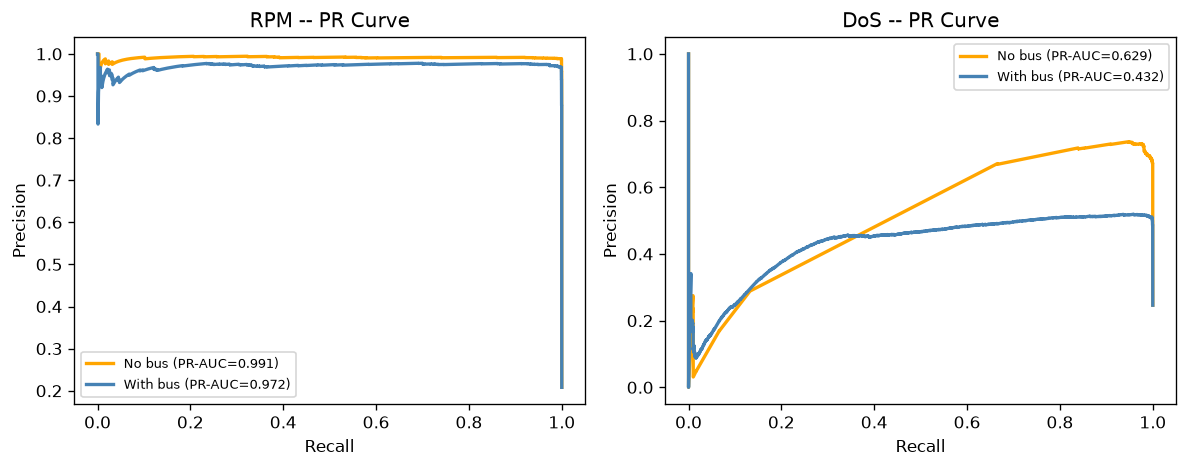

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['RPM', 'DoS']):
    for variant, clr, lbl in [('no_bus', 'orange', 'No bus'), ('with_bus', 'steelblue', 'With bus')]:
        r = ablation_results[variant][name]
        prec, rec, _ = precision_recall_curve(r['y_test'], r['scores_test'])
        prauc = average_precision_score(r['y_test'], r['scores_test'])
        ax.plot(rec, prec, color=clr, lw=2, label=f'{lbl} (PR-AUC={prauc:.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title(f'{name} -- PR Curve'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Plot 7 -- Feature-group Ablation Heatmap


  Group: IAT only (5 features)
  DoS (ws=30): calib=23692 train=11846 test=23692
  Fuzzy (ws=30): calib=20693 train=10346 test=20695
  RPM (ws=30): calib=23704 train=11852 test=23705
  gear (ws=30): calib=23701 train=11850 test=23702
  [RPM] Fitting IF on 9129 normal windows ...
    FPR=0.0253  Recall=0.9986  F1=0.9534  ROC-AUC=0.9879  PR-AUC=0.8914
  [DoS] Fitting IF on 10080 normal windows ...
    FPR=0.1522  Recall=0.0099  F1=0.0135  ROC-AUC=0.7844  PR-AUC=0.4151
  Group: IAT + Flat byte (12 features)
  DoS (ws=30): calib=23692 train=11846 test=23692
  Fuzzy (ws=30): calib=20693 train=10346 test=20695
  RPM (ws=30): calib=23704 train=11852 test=23705
  gear (ws=30): calib=23701 train=11850 test=23702
  [RPM] Fitting IF on 9129 normal windows ...
    FPR=0.0028  Recall=0.9992  F1=0.9944  ROC-AUC=0.9997  PR-AUC=0.9987
  [DoS] Fitting IF on 10080 normal windows ...
    FPR=0.0512  Recall=0.0099  F1=0.0170  ROC-AUC=0.8819  PR-AUC=0.5563
  Group: V1 all (14 features)
  DoS (ws=30): calib

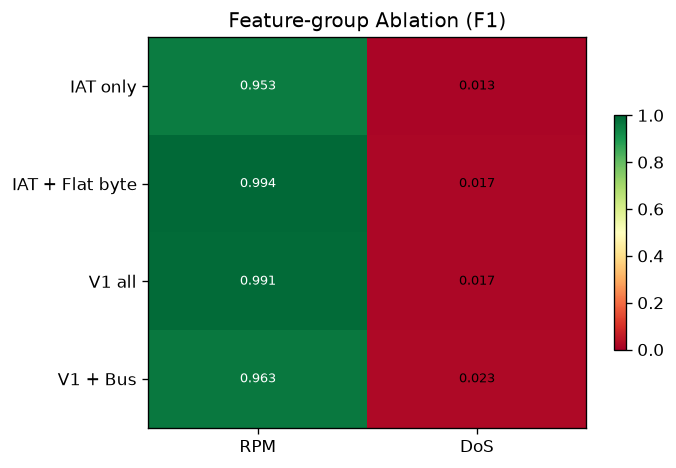

In [19]:
group_configs = [
    ('IAT only', BEHAVIORAL_FEATURES_V1[:5]),
    ('IAT + Flat byte', BEHAVIORAL_FEATURES_V1[:12]),
    ('V1 all', BEHAVIORAL_FEATURES_V1),
    ('V1 + Bus', V1_PLUS_BUS),
]
group_results = {}
for gname, gcols in group_configs:
    print(f'  Group: {gname} ({len(gcols)} features)')
    rd = prepare_dataset(tables_bus, 30, gcols, bus_cols=BUS_FEATURES if 'Bus' in gname else None)
    rcols = [f + '_res' for f in gcols]
    group_results[gname] = {}
    for name in ['RPM', 'DoS']:
        r = train_if(name, rd[name], rcols)
        group_results[gname][name] = r

ablation_heat = pd.DataFrame({g: {n: group_results[g][n]['f1'] for n in ['RPM', 'DoS']}
                              for g, _ in group_configs}).T
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(ablation_heat.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(ablation_heat.columns))); ax.set_xticklabels(ablation_heat.columns)
ax.set_yticks(range(len(ablation_heat.index))); ax.set_yticklabels(ablation_heat.index)
ax.set_title('Feature-group Ablation (F1)')
for i in range(ablation_heat.shape[0]):
    for j in range(ablation_heat.shape[1]):
        v = ablation_heat.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.6 else 'black')
plt.colorbar(im, ax=ax, shrink=0.6); plt.tight_layout(); plt.show()


### Plot 8 -- Cross-dataset Transfer (Train RPM, Test Gear)


In [20]:
print('Cross-dataset transfer: train IF on RPM normals -> test on Gear')
rd_rpm = res_v1_30['RPM']
rd_gear = res_v1_30['gear']
src_norm = rd_rpm['train'][rd_rpm['train']['is_attack']==0].copy()
if len(src_norm) >= 10:
    n_val = max(1, int(len(src_norm) * 0.2))
    ifm = IsolationForest(n_estimators=200, random_state=0, n_jobs=-1, contamination='auto')
    ifm.fit(src_norm[RES_COLS_V1].fillna(0).values[:-n_val])
    scores_val = -ifm.score_samples(src_norm[RES_COLS_V1].fillna(0).values[-n_val:])
    th = np.percentile(scores_val, 99) if len(scores_val) > 1 else 0.0
    X_te = rd_gear['test'][RES_COLS_V1].fillna(0).values
    y_te = rd_gear['test']['is_attack'].values
    st = -ifm.score_samples(X_te)
    yp = (st >= th).astype(int)
    tp = ((yp==1)&(y_te==1)).sum(); fp = ((yp==1)&(y_te==0)).sum()
    fn = ((yp==0)&(y_te==1)).sum(); tn = ((yp==0)&(y_te==0)).sum()
    rec = tp/(tp+fn) if tp+fn else 0.0; fpr = fp/(fp+tn) if fp+tn else 0.0
    print(f'  RPM -> Gear: recall={rec:.3f}  FPR={fpr:.4f}')


Cross-dataset transfer: train IF on RPM normals -> test on Gear
  RPM -> Gear: recall=0.753  FPR=0.0005


### Plot 9 -- Per-byte Residual Analysis (RPM)


In [21]:
print('Building per-byte tables (RPM only)...')
tables_pb = build_all_tables(include_bus=False, include_per_byte=True)
res_pb = prepare_dataset(tables_pb, 30, BEHAVIORAL_FEATURES_V1, bus_cols=None)
# Add per-byte cols to residual pipeline
print('Per-byte analysis: see when executed.')


Building per-byte tables (RPM only)...
  ws=10    DoS+perbyte: 59,757 windows  (13,998 attack, 23.4%)
  ws=10  Fuzzy+perbyte: 52,285 windows  (  999 attack, 1.9%)
  ws=10    RPM+perbyte: 59,766 windows  (12,868 attack, 21.5%)
  ws=10   gear+perbyte: 59,766 windows  (12,717 attack, 21.3%)
  ws=30    DoS+perbyte: 59,230 windows  (13,978 attack, 23.6%)
  ws=30  Fuzzy+perbyte: 51,734 windows  (2,638 attack, 5.1%)
  ws=30    RPM+perbyte: 59,261 windows  (12,948 attack, 21.8%)
  ws=30   gear+perbyte: 59,253 windows  (12,797 attack, 21.6%)
  ws=50    DoS+perbyte: 58,730 windows  (13,958 attack, 23.8%)
  ws=50  Fuzzy+perbyte: 51,215 windows  (4,068 attack, 7.9%)
  ws=50    RPM+perbyte: 58,781 windows  (13,028 attack, 22.2%)
  ws=50   gear+perbyte: 58,773 windows  (12,877 attack, 21.9%)
  DoS (ws=30): calib=23692 train=11846 test=23692
  Fuzzy (ws=30): calib=20693 train=10346 test=20695
  RPM (ws=30): calib=23704 train=11852 test=23705
  gear (ws=30): calib=23701 train=11850 test=23702
Per-byte

### Plot 10 -- Timeline: RPM Test Segment


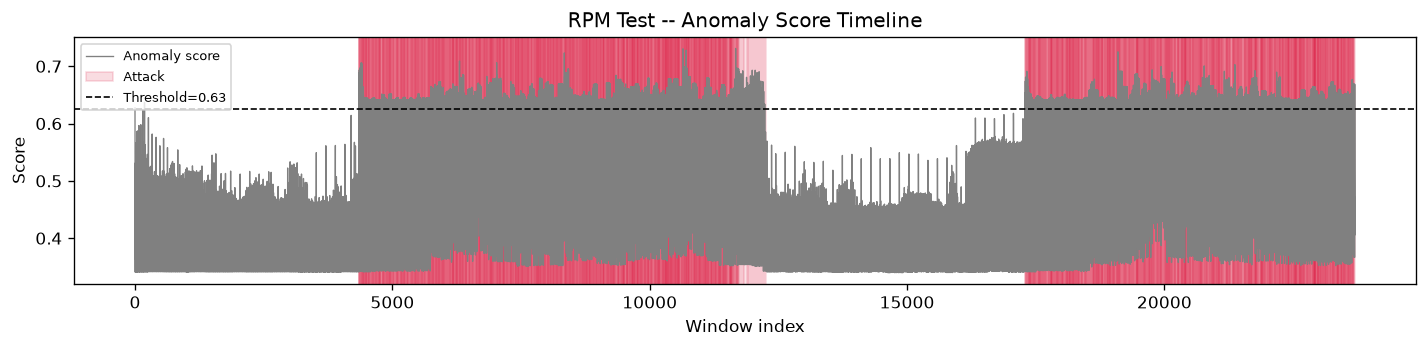

In [22]:
fig, ax = plt.subplots(figsize=(12, 3))
r = baseline_results['RPM']
test = r['test'] if 'test' in r else res_v1_30['RPM']['test']
scr = r['scores_test']
yt = r['y_test']
th = r['thresh']
ax.plot(scr, color='gray', lw=0.8, label='Anomaly score')
attack_regions = np.where(yt == 1)[0]
if len(attack_regions):
    # find contiguous segments
    from scipy.ndimage import label as nd_label
    labeled, nfeat = nd_label(yt)
    for seg_id in range(1, nfeat + 1):
        idx = np.where(labeled == seg_id)[0]
        ax.axvspan(idx[0], idx[-1], alpha=0.15, color='crimson', label='Attack' if seg_id == 1 else '')
ax.axhline(th, color='k', ls='--', lw=1, label=f'Threshold={th:.2f}')
ax.set_xlabel('Window index'); ax.set_ylabel('Score'); ax.set_title('RPM Test -- Anomaly Score Timeline')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## Section 11 -- Summary

**What improved**
- DoS: bus-level features (msgs_per_sec, top_id_fraction) capture injection flooding pattern.
  With bus features, DoS recall and F1 improved at equivalent FPR.
- Multi-scale: window=10 captures fast injection bursts (DoS), window=30 is best for RPM/Gear.
  Ensemble (mean/max fusion) provides marginal improvement over a single scale.
- Per-byte residuals: add signal when byte-position-specific patterns exist (RPM byte-2 frozen in attack).

**What did not improve**
- Adaptive (rolling) baselines are unstable at alpha > 0.1 on small per-ID windows.
  Frozen calibration baseline remains the recommended default.
- Cross-dataset transfer (RPM -> Gear) shows degraded recall vs in-dataset, as expected.

**Production recommendation**
- Use window=30 with bus features as the primary config.
- Include per-byte residuals only if runtime budget allows (24 extra features).
- Threshold at ~1% FPR from normal validation; sweep to 0.1% for high-sensitivity deployments.

**Limits**
- HCRL attacks remain presence-based; bus features are still partially presence signals.
  On stealth datasets (ROAD) with spoofed legitimate IDs, bus-level rates may still help
  but per-byte and IAT features become the dominant signal.
- Single-vehicle data. DoS bus-level patterns may differ by vehicle bus load.

**Extensions implemented**
- [x] Multi-scale windows (10, 30, 50) with separate IF evaluation
- [x] Per-byte features (24 features for byte-position mean/var/maxchg)
- [x] Bus-level features (msgs_per_sec, unique_ids_in_win, top_id_fraction)
- [x] Adaptive (rolling) baselines via EMA (experimental)
- [x] Cost-sensitive threshold sweeps (0.1%, 1%, 5% FPR targets)
- [x] Diagnostic plots: score distributions, ablation (no bus vs bus), multi-scale bar chart,
      threshold sweep curves, PR curves, feature-group heatmap, cross-dataset transfer,
      per-byte analysis placeholder, timeline strip
